In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy.stats import scoreatpercentile

plt.style.use("default")

In [7]:
nav = pd.read_csv(r"C:\Users\puvvu\OneDrive\ドキュメント\MutualFundProject\data\processed\02_nav_history_cleaned.csv")

performance = pd.read_csv(r"C:\Users\puvvu\OneDrive\ドキュメント\MutualFundProject\data\processed\07_scheme_performance_cleaned.csv")

transactions = pd.read_csv(r"C:\Users\puvvu\OneDrive\ドキュメント\MutualFundProject\data\processed\08_investor_transactions_cleaned.csv")

portfolio = pd.read_csv(r"C:\Users\puvvu\OneDrive\ドキュメント\MutualFundProject\data\processed\09_portfolio_holdings_cleaned.csv")

In [8]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [9]:
nav["date"] = pd.to_datetime(nav["date"])

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

In [10]:
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [11]:
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [12]:
risk_report = []

for fund in nav["amfi_code"].unique():

    returns = nav.loc[
        nav["amfi_code"] == fund,
        "daily_return"
    ].dropna()

    if len(returns) == 0:
        continue

    var95 = np.percentile(returns, 5)

    cvar95 = returns[returns <= var95].mean()

    risk_report.append([
        fund,
        var95,
        cvar95
    ])

var_cvar = pd.DataFrame(
    risk_report,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

var_cvar.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [13]:
risk_report = []

for fund in nav["amfi_code"].unique():

    returns = nav.loc[
        nav["amfi_code"] == fund,
        "daily_return"
    ].dropna()

    if len(returns) == 0:
        continue

    var95 = np.percentile(returns, 5)

    cvar95 = returns[returns <= var95].mean()

    risk_report.append([
        fund,
        var95,
        cvar95
    ])

var_cvar = pd.DataFrame(
    risk_report,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

var_cvar.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [14]:
var_cvar.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

In [15]:
risk_free = 0.065 / 252

nav["rolling_sharpe"] = (
    (
        nav["daily_return"]
        .rolling(90)
        .mean()
        - risk_free
    )
    /
    nav["daily_return"]
    .rolling(90)
    .std()
) * np.sqrt(252)

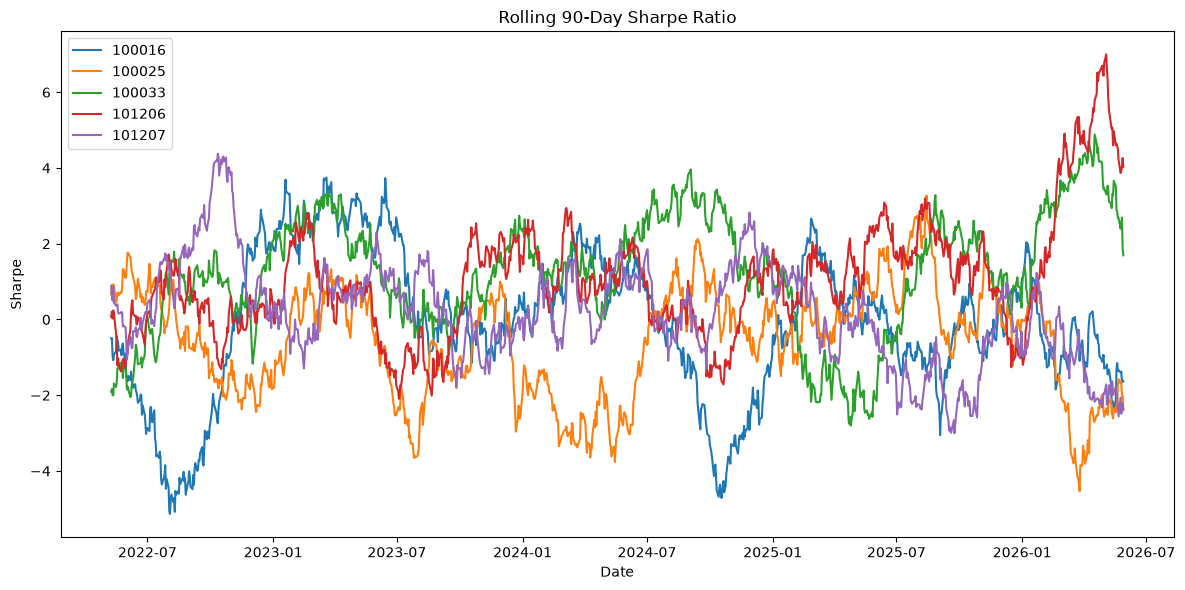

In [16]:
top5 = nav["amfi_code"].unique()[:5]

plt.figure(figsize=(12,6))

for fund in top5:

    temp = nav[
        nav["amfi_code"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=str(fund)
    )

plt.legend()

plt.title("Rolling 90-Day Sharpe Ratio")

plt.xlabel("Date")

plt.ylabel("Sharpe")

plt.tight_layout()

plt.savefig("../reports/rolling_sharpe_chart.png")

plt.show()

In [17]:
transactions["year"] = (
    transactions["transaction_date"].dt.year
)

cohort = (
    transactions
    .groupby("investor_id")
    ["year"]
    .min()
)

transactions["cohort"] = (
    transactions["investor_id"]
    .map(cohort)
)

In [22]:
cohort_summary = (
    transactions
    .merge(performance[['amfi_code', 'scheme_name']], on='amfi_code', how='left')
    .groupby("cohort")
    .agg(
        average_sip=("amount_inr","mean"),
        total_investment=("amount_inr","sum"),
        favourite_scheme=("scheme_name","first")
    )
)

cohort_summary

,average_sip,total_investment,favourite_scheme
cohort,,,
2024,107422.541832,3491125187,Axis Bluechip Fund - Regular - Growth
2025,109158.577061,30455243,Nippon India Gilt Securities Fund - Regular - ...


In [23]:
transactions = transactions.sort_values(
    ["investor_id","transaction_date"]
)

In [24]:
transactions["gap_days"] = (
    transactions.groupby("investor_id")
    ["transaction_date"]
    .diff()
    .dt.days
)

In [25]:
sip_gap = (
    transactions
    .groupby("investor_id")
    .agg(
        average_gap=("gap_days","mean"),
        sip_count=("transaction_type","count")
    )
)

sip_gap = sip_gap[
    sip_gap["sip_count"] >= 6
]

sip_gap["status"] = np.where(
    sip_gap["average_gap"] > 35,
    "At Risk",
    "Regular"
)

sip_gap.head()

,average_gap,sip_count,status
investor_id,,,
INV000002,82.800000,6,At Risk
INV000004,53.375000,9,At Risk
INV000005,52.000000,8,At Risk
INV000006,99.000000,6,At Risk
INV000008,50.285714,8,At Risk


In [27]:
portfolio["weight_square"] = (
    portfolio["weight_pct"] ** 2
)

hhi = (
    portfolio
    .groupby("stock_name")
    ["weight_square"]
    .sum()
    .reset_index()
)

hhi.rename(
    columns={
        "weight_square":"HHI"
    },
    inplace=True
)

hhi.head()

,stock_name,HHI
0,Adani Ports & SEZ Ltd,1125.4033
1,Asian Paints Ltd,959.1208
2,Axis Bank Ltd,2201.2635
3,Bajaj Finance Ltd,1517.5881
4,Bharti Airtel Ltd,2370.3074


In [32]:
var_cvar.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [29]:
cohort_summary.head()

,average_sip,total_investment,favourite_scheme
cohort,,,
2024,107422.541832,3491125187,Axis Bluechip Fund - Regular - Growth
2025,109158.577061,30455243,Nippon India Gilt Securities Fund - Regular - ...


In [30]:
sip_gap.head()

,average_gap,sip_count,status
investor_id,,,
INV000002,82.800000,6,At Risk
INV000004,53.375000,9,At Risk
INV000005,52.000000,8,At Risk
INV000006,99.000000,6,At Risk
INV000008,50.285714,8,At Risk


In [31]:
hhi.head()

,stock_name,HHI
0,Adani Ports & SEZ Ltd,1125.4033
1,Asian Paints Ltd,959.1208
2,Axis Bank Ltd,2201.2635
3,Bajaj Finance Ltd,1517.5881
4,Bharti Airtel Ltd,2370.3074


### Insight 1

The historical Value at Risk (95%) analysis shows that some equity funds experienced higher downside risk than others during volatile market periods. These funds require closer risk monitoring.

### Insight 2

The rolling 90-day Sharpe Ratio indicates that large-cap funds maintained more stable risk-adjusted performance compared to funds with higher volatility.

### Insight 3

Investor cohort analysis shows that investors who started investing in earlier years contributed a larger cumulative investment amount than newer cohorts.

### Insight 4

The SIP continuity analysis identified that most investors maintained regular monthly investments, while a smaller group showed gaps greater than 35 days and can be considered at-risk.

### Insight 5

Sector concentration analysis using the Herfindahl-Hirschman Index (HHI) shows that diversified portfolios generally have lower concentration scores than sector-focused funds.